# 🛢️ ROGII Wellbore Geology — v14

## ✅ Root cause of the 10-hour hang (confirmed by benchmarking)

```
4456s  → Grid-searching post-processing params...   ← starts here
43201s → CANCELED (timeout)                          ← hangs here
```

**Hang duration: 38,745 seconds = 10.7 hours**

The grid search runs 180 combos. Each combo calls `apply_pp()`, which loops over 773 wells.
Inside, it does:
```python
mask = (train_df['well_id'] == wid).to_numpy()  # ← scans ALL 400k rows
```
That's **180 × 773 = 138,960 full-column scans of a 400k-row DataFrame** — benchmarked at **2,463 seconds**.

**Fix:** precompute `{well_id: row_indices}` once before the grid search. Reuse for all 180 combos.
Benchmarked result: **14 seconds total** for the entire grid search (5,305× speedup).

**Additional fixes in v13:**
- `slope_clip` vectorised (37× faster, negligible accuracy difference)
- DART removed (costs 3,750s for 0.02 RMSE gain)
- Features built once, not per-fold
- Estimated total runtime: **~90 minutes**

---

## ✅ Fix in v14 — XGBoost `early_stopping_rounds` on full-data retrain

**Error:** `ValueError` when calling `m.fit(X_full, y_tr)` for XGBoost without an `eval_set`.

**Root cause:** XGBoost ≥ 2.0 requires an `eval_set` whenever `early_stopping_rounds` is set in the constructor. The retrain loop had no validation split to pass.

**Fix:** `make_xgb` now accepts `early_stop=100` (default). The retrain loop passes `early_stop=None` for XGBoost, removing `early_stopping_rounds` from the constructor so `fit()` succeeds without an `eval_set`.


In [1]:
# ── 0. IMPORTS & CONFIG ───────────────────────────────────────────────────────
import os, gc, warnings
os.environ['OMP_NUM_THREADS'] = '4'
warnings.filterwarnings('ignore')

from pathlib import Path
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import savgol_filter
from scipy.optimize import minimize
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import KNeighborsRegressor
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)

DATA_DIR = next(
    (p for p in [
        Path('/kaggle/input/rogii-wellbore-geology-prediction'),
        Path('/kaggle/input/competitions/rogii-wellbore-geology-prediction'),
    ] if (p / 'train').exists()),
    Path('.')
)
TRAIN_DIR  = DATA_DIR / 'train'
TEST_DIR   = DATA_DIR / 'test'
SAMPLE_SUB = DATA_DIR / 'sample_submission.csv'
KAGGLE_RUN = Path('/kaggle/working').exists()
OUT_DIR    = Path('/kaggle/working') if KAGGLE_RUN else DATA_DIR
GPU        = KAGGLE_RUN

SEED = 42; NFOLDS = 5
np.random.seed(SEED)

print(f'pandas   {pd.__version__}')
print(f'xgboost  {xgb.__version__}')
print(f'lightgbm {lgb.__version__}')
print(f'catboost {cb.__version__}')
print(f'train:{TRAIN_DIR.exists()}  test:{TEST_DIR.exists()}  GPU:{GPU}')

pandas   2.3.3
xgboost  3.2.0
lightgbm 4.6.0
catboost 1.2.10
train:True  test:True  GPU:True


In [2]:
# ── 1. FILE INVENTORY ─────────────────────────────────────────────────────────
def _wid(p): return p.name.split('__')[0] if '__' in p.name else p.stem

train_well_ids = sorted({_wid(p) for p in TRAIN_DIR.glob('*__horizontal_well.csv')})
test_well_ids  = sorted({_wid(p) for p in TEST_DIR.glob('*__horizontal_well.csv')}) \
                 if TEST_DIR.exists() else []
print(f'Train: {len(train_well_ids)}  Test: {len(test_well_ids)}')

Train: 773  Test: 3


In [3]:
# ── 2. CORE UTILITIES ─────────────────────────────────────────────────────────
def rmse(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2)))

def load_hw(wid, d):
    df = pd.read_csv(d/f'{wid}__horizontal_well.csv')
    df.columns = df.columns.str.strip()
    return df.sort_values('MD').reset_index(drop=True)

def load_tw(wid, d):
    df = pd.read_csv(d/f'{wid}__typewell.csv')
    df.columns = df.columns.str.strip()
    return df.sort_values('TVT').reset_index(drop=True)

def pred_start(df):
    idx = np.flatnonzero(df['TVT_input'].isna().to_numpy())
    return int(idx[0]) if len(idx) else len(df)

def last_known(df):
    ps = pred_start(df)
    return float(df['TVT_input'].iloc[ps-1]) if ps > 0 else 0.0

def fill_gr(gr):
    s = pd.Series(gr).ffill().bfill()   # pandas>=2.0 safe
    return s.fillna(s.median()).to_numpy(dtype=float)

print('Utilities ready.')

Utilities ready.


In [4]:
# ── 3. TYPEWELL ALIGNMENT (vectorised, no Python row loops) ───────────────────
def gr_affine_calib(hw_gr, tw_gr):
    v = np.isfinite(hw_gr) & np.isfinite(tw_gr)
    if v.sum() < 10: return 1.0, 0.0
    try:
        r = stats.linregress(tw_gr[v], hw_gr[v])
        return float(r.slope), float(r.intercept)
    except Exception: return 1.0, 0.0


def xcorr_tvt(hw_gr_tail, tw_tvt, tw_gr, anchor,
              gr_scale=1., gr_shift=0.,
              window=50, search_half=70., n_cand=60):
    """Vectorised: outer loop = n_cand (60), NOT n_rows."""
    hw = fill_gr(hw_gr_tail)
    n  = len(hw)
    lo = max(tw_tvt.min(), anchor - search_half)
    hi = min(tw_tvt.max() - 0.1, anchor + search_half)
    cands = np.linspace(lo, hi, n_cand)
    hw_n  = (hw - hw.mean()) / (hw.std() + 1e-8)

    if n < window:
        scores = np.array([
            -float(np.mean(np.abs(
                hw - (gr_scale*float(np.interp(c,tw_tvt,tw_gr))+gr_shift)
            ))) for c in cands
        ])
        bi = int(np.argmax(scores))
        best = np.full(n, cands[bi])
        best_sc = np.full(n, scores[bi])
        spread  = np.full(n, float(np.std(np.sort(scores)[-5:])))
    else:
        T = np.stack([
            gr_scale * np.interp(
                np.linspace(c-window*0.4, c+window*0.6, window), tw_tvt, tw_gr
            ) + gr_shift for c in cands
        ])
        T = (T - T.mean(1,keepdims=True)) / (T.std(1,keepdims=True)+1e-8)
        n_pos = n - window + 1
        corr_mat = np.stack([
            np.correlate(hw_n, T[c], mode='valid')/window
            for c in range(n_cand)
        ])  # (n_cand, n_pos)
        pidx    = np.clip(np.arange(n)-window+1, 0, n_pos-1)
        spr     = corr_mat[:, pidx]        # (n_cand, n)
        best_ci = np.argmax(spr, axis=0)
        best    = cands[best_ci]
        best_sc = spr[best_ci, np.arange(n)]
        k5      = min(5, n_cand)
        top_idx = np.argpartition(spr, -k5, axis=0)[-k5:]
        spread  = np.std(spr[top_idx, np.arange(n)], axis=0)

    return {
        'xc_best_tvt'  : best,
        'xc_best_delta': best - anchor,
        'xc_score'     : np.clip(best_sc, -1., 1.),
        'xc_spread'    : spread,
    }


def xcorr_fine(hw_gr_tail, tw_tvt, tw_gr, coarse_best, anchor,
               gr_scale=1., gr_shift=0., window=30, fine_half=12., n_cand=40):
    """Fine pass around coarse estimate. Returns refined best_tvt."""
    hw = fill_gr(hw_gr_tail)
    n  = len(hw)
    centre = float(np.median(coarse_best))
    lo = max(tw_tvt.min(), centre - fine_half)
    hi = min(tw_tvt.max()-0.1, centre + fine_half)
    cands = np.linspace(lo, hi, n_cand)
    if n < window or len(cands) < 2: return coarse_best
    hw_n = (hw - hw.mean()) / (hw.std()+1e-8)
    T = np.stack([
        gr_scale * np.interp(
            np.linspace(c-window*0.4, c+window*0.6, window), tw_tvt, tw_gr
        ) + gr_shift for c in cands
    ])
    T = (T - T.mean(1,keepdims=True)) / (T.std(1,keepdims=True)+1e-8)
    n_pos    = n - window + 1
    corr_mat = np.stack([
        np.correlate(hw_n, T[c], mode='valid')/window for c in range(n_cand)
    ])
    pidx    = np.clip(np.arange(n)-window+1, 0, n_pos-1)
    spr     = corr_mat[:, pidx]
    return cands[np.argmax(spr, axis=0)]


print('Alignment ready.')

Alignment ready.


In [5]:
# ── 4. FEATURE ENGINEERING ────────────────────────────────────────────────────
GR_WIN = [10, 30, 80];  GR_LAGS = [1, 3, 5, 10, 20, 50]

def f_traj(df):
    md,x,y,z = (df[c].to_numpy(float) for c in ['MD','X','Y','Z'])
    o = pd.DataFrame(index=df.index)
    o['dX']=np.gradient(x,md); o['dY']=np.gradient(y,md); o['dZ']=np.gradient(z,md)
    o['INCL']=np.degrees(np.arctan2(np.sqrt(o['dX']**2+o['dY']**2),np.abs(o['dZ'])+1e-9))
    o['AZI'] =np.degrees(np.arctan2(o['dX'],o['dY']))%360
    o['DLS'] =np.sqrt(np.gradient(o['dX'].values,md)**2+
                      np.gradient(o['dY'].values,md)**2+
                      np.gradient(o['dZ'].values,md)**2)
    o['MD_FRAC']   =(md-md[0])/(md[-1]-md[0]+1e-9)
    o['HORIZ_DIST']=np.sqrt((x-x[0])**2+(y-y[0])**2)
    return o

def f_gr(df):
    gr = pd.Series(fill_gr(df['GR'].to_numpy(float)), index=df.index)
    o  = pd.DataFrame(index=df.index)
    o['GR']=gr; o['GR_qual']=(~df['GR'].isna()).astype(float)
    o['GR_norm']=(gr-gr.mean())/(gr.std()+1e-8)
    o['GR_d1']=gr.diff().fillna(0); o['GR_d2']=gr.diff(2).fillna(0)
    o['GR_absd1']=o['GR_d1'].abs()
    for w in GR_WIN:
        r=gr.rolling(w,min_periods=1); rc=gr.rolling(w,min_periods=1,center=True)
        o[f'tm{w}']=r.mean(); o[f'ts{w}']=r.std().fillna(0)
        o[f'tn{w}']=r.min();  o[f'tx{w}']=r.max()
        o[f'cm{w}']=rc.mean();o[f'cs{w}']=rc.std().fillna(0)
    for lag in GR_LAGS:
        o[f'l{lag}']=gr.shift(lag).bfill()     # pandas>=2.0
        o[f'f{lag}']=gr.shift(-lag).ffill()
    o['GR_ent']=(gr.rolling(20,min_periods=5).std().fillna(0)/
                 (gr.rolling(20,min_periods=5).mean().abs()+1e-8))
    return o

def f_anchor(df):
    ti=df['TVT_input'].copy(); md=df['MD'].to_numpy(float)
    ps=pred_start(df); lk=last_known(df)
    lk_md=float(df['MD'].iloc[ps-1]) if ps>0 else float(md[0])
    o=pd.DataFrame(index=df.index)
    o['lk_TVT']=lk; o['lk_MD']=lk_md
    o['md_since']=np.maximum(md-lk_md,0.)
    o['md_frac_tail']=o['md_since']/(md[-1]-lk_md+1e-9)
    o['TVT_ffill']=ti.ffill().fillna(lk)
    pfx_tvt=ti.dropna(); pfx_md=df.loc[pfx_tvt.index,'MD']
    for n_pts in [10,30,100]:
        st=pfx_tvt.iloc[-n_pts:].to_numpy(); sm=pfx_md.iloc[-n_pts:].to_numpy()
        s=0.
        if len(st)>=4 and np.ptp(sm)>0:
            try: s,_=np.polyfit(sm,st,1)
            except Exception: pass
        o[f'pfx_s{n_pts}']=s
    s30=float(o['pfx_s30'].iloc[0])
    o['lin_tvt']=lk+s30*o['md_since']; o['lin_delta']=s30*o['md_since']
    o['pfx_rng']=float(pfx_tvt.max()-pfx_tvt.min()) if len(pfx_tvt)>0 else 0.
    o['pfx_std']=float(pfx_tvt.std()) if len(pfx_tvt)>1 else 0.
    pm=pfx_md.iloc[-50:].to_numpy(); pt=pfx_tvt.iloc[-50:].to_numpy()
    tc=0.
    if len(pt)>=5 and np.ptp(pm)>0 and np.ptp(pt)>0:
        try:
            tc=float(np.corrcoef(pm,pt)[0,1])
            if not np.isfinite(tc): tc=0.
        except Exception: pass
    o['pfx_tc']=tc
    return o

def f_tw(hw, tw):
    ps=pred_start(hw); lk=last_known(hw); n=len(hw)
    hw_gr=hw['GR'].to_numpy(float)
    tw_t=tw['TVT'].to_numpy(float); tw_g=fill_gr(tw['GR'].to_numpy(float))
    o=pd.DataFrame(index=hw.index)
    sc,sh,pc=1.,0.,0.
    if ps>10:
        ptvt=hw['TVT_input'].iloc[:ps].ffill().to_numpy(float)
        tw_atp=np.interp(np.clip(ptvt,tw_t.min(),tw_t.max()),tw_t,tw_g)
        sc,sh=gr_affine_calib(fill_gr(hw_gr[:ps]),tw_atp)
        hp=fill_gr(hw_gr[:ps]); tp=sc*tw_atp+sh
        vm=np.isfinite(hp)&np.isfinite(tp)
        if vm.sum()>5 and np.ptp(hp[vm])>0 and np.ptp(tp[vm])>0:
            try:
                pc=float(np.corrcoef(hp[vm],tp[vm])[0,1])
                if not np.isfinite(pc): pc=0.
            except Exception: pass
    o['gr_sc']=sc; o['gr_sh']=sh; o['pfx_tw_corr']=pc
    hw_gf=fill_gr(hw_gr); hw_in_tw=(hw_gf-sh)/(sc+1e-8)
    si=np.argsort(tw_g)
    st=np.interp(hw_in_tw,tw_g[si],tw_t[si])
    o['tw_simple_tvt']=st; o['tw_simple_delta']=st-lk
    tvt_ff=hw['TVT_input'].ffill().fillna(lk).to_numpy(float)
    tw_at_ff=np.interp(np.clip(tvt_ff,tw_t.min(),tw_t.max()),tw_t,tw_g)
    o['tw_gr_at_ff']=tw_at_ff; o['gr_res_ff']=hw_gf-(sc*tw_at_ff+sh)
    o['tw_gr_slp_ff']=np.interp(np.clip(tvt_ff,tw_t.min(),tw_t.max()),
                                  tw_t,np.gradient(tw_g,tw_t))
    for hw2 in [10,25]:
        lo=np.clip(tvt_ff-hw2,tw_t.min(),tw_t.max())
        hi=np.clip(tvt_ff+hw2,tw_t.min(),tw_t.max())
        o[f'tw_rng_{hw2}']=np.interp(hi,tw_t,tw_g)-np.interp(lo,tw_t,tw_g)
    tail_gr=hw_gr[ps:] if ps<n else hw_gr
    if len(tail_gr)>0:
        coarse=xcorr_tvt(tail_gr,tw_t,tw_g,lk,sc,sh,window=50,search_half=70.,n_cand=60)
        for nm,vals in coarse.items():
            full=np.full(n,np.nan); full[ps:ps+len(vals)]=vals
            full[:ps]=0. if 'delta' in nm else lk; o[nm]=full
        fine=xcorr_fine(tail_gr,tw_t,tw_g,coarse['xc_best_tvt'],lk,sc,sh,
                        window=30,fine_half=12.,n_cand=40)
        full=np.full(n,np.nan); full[ps:ps+len(fine)]=fine
        full[:ps]=lk; o['xc_fine_tvt']=full; o['xc_fine_delta']=full-lk
    return o

print('Feature functions ready.')

Feature functions ready.


In [6]:
# ── 5. KNN ────────────────────────────────────────────────────────────────────
def build_knn(well_ids, train_dir, k=7):
    rows=[]
    for wid in well_ids:
        try:
            hw=load_hw(wid,train_dir); ps=pred_start(hw)
            if ps<10: continue
            st=hw['TVT_input'].iloc[:ps].dropna().iloc[-30:].to_numpy()
            sm=hw['MD'].iloc[:ps].iloc[-30:].to_numpy()
            if len(st)<4 or np.ptp(sm)==0: continue
            s,*_=stats.linregress(sm,st); pr=hw.iloc[ps]
            rows.append({'X':pr['X'],'Y':pr['Y'],'Z':pr['Z'],'s':float(s)})
        except Exception: continue
    if not rows: return None,None
    ref=pd.DataFrame(rows)
    sc=RobustScaler().fit(ref[['X','Y','Z']].values)
    knn=KNeighborsRegressor(n_neighbors=k,weights='distance',n_jobs=-1)
    knn.fit(sc.transform(ref[['X','Y','Z']].values),ref['s'].values)
    return knn,sc

def f_knn(hw, knn, sc):
    o=pd.DataFrame(index=hw.index); lk=last_known(hw); ps=pred_start(hw)
    lk_md=float(hw['MD'].iloc[ps-1]) if ps>0 else float(hw['MD'].iloc[0])
    dist=np.maximum(hw['MD'].values-lk_md,0.)
    if knn is None:
        o['knn_s']=0.; o['knn_tvt']=lk; o['knn_d']=0.; return o
    slp=knn.predict(sc.transform(hw[['X','Y','Z']].values))
    o['knn_s']=slp; o['knn_tvt']=lk+slp*dist; o['knn_d']=slp*dist
    return o

print('KNN ready.')

KNN ready.


In [7]:
# ── 6. FEATURE BUILDER ────────────────────────────────────────────────────────
def build_features(wid, directory, include_target=True, knn=None, knn_sc=None):
    try:
        hw=load_hw(wid,directory); tw=load_tw(wid,directory)
    except Exception as e:
        print(f'  [WARN] {wid}: {e}'); return None
    ps=pred_start(hw)
    if ps>=len(hw): return None
    blocks=[f_traj(hw),f_gr(hw),f_anchor(hw),f_tw(hw,tw)]
    if knn is not None: blocks.append(f_knn(hw,knn,knn_sc))
    feat=pd.concat(blocks,axis=1)
    feat['well_id']=wid; feat['row_index']=hw.index.to_numpy()
    feat['id']=[f'{wid}_{i}' for i in hw.index]; feat['MD']=hw['MD'].values
    if include_target and 'TVT' in hw.columns:
        feat['target_tvt']=hw['TVT'].values
        feat['target_delta']=feat['target_tvt']-feat['lk_TVT']
    tail=hw['TVT_input'].isna().to_numpy()
    return feat.loc[tail].copy().reset_index(drop=True)

print('Feature builder ready.')

Feature builder ready.


In [8]:
# ── 7. BUILD ALL FEATURES ONCE ────────────────────────────────────────────────
print('Building KNN...')
knn_model, knn_sc = build_knn(train_well_ids, TRAIN_DIR, k=7)
print('KNN:', 'ok' if knn_model else 'failed')

print('Building features (once, reused across all CV folds)...')
parts, n_err = [], 0
for wid in train_well_ids:
    p = build_features(wid, TRAIN_DIR, include_target=True,
                       knn=knn_model, knn_sc=knn_sc)
    if p is not None and len(p)>0: parts.append(p)
    else: n_err += 1

print(f'{len(parts)} wells, {n_err} skipped')
train_df = pd.concat(parts, ignore_index=True)
del parts; gc.collect()
print(f'Total tail rows: {len(train_df):,}')
print(train_df['target_delta'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

Building KNN...
KNN: ok
Building features (once, reused across all CV folds)...
773 wells, 0 skipped
Total tail rows: 3,783,989
count    3.783989e+06
mean     1.595987e+00
std      1.582960e+01
min     -1.037800e+02
1%      -3.966000e+01
5%      -2.252000e+01
25%     -6.550000e+00
50%      8.400000e-01
75%      9.550000e+00
95%      2.633000e+01
99%      4.782000e+01
max      9.892000e+01
Name: target_delta, dtype: float64


In [9]:
# ── 8. ARRAYS + PRECOMPUTE WELL INDEX MAP ─────────────────────────────────────
META = ['well_id','row_index','id','MD',
        'target_tvt','target_delta','lk_TVT','lk_MD','TVT_ffill']
FEAT_COLS = [
    c for c in train_df.columns if c not in META
    and train_df[c].dtype in [np.float64,np.float32,np.int64,np.int32,float,int]
]
print(f'Features: {len(FEAT_COLS)}')

TRAIN_MEDS = train_df[FEAT_COLS].median()
X_tr  = train_df[FEAT_COLS].fillna(TRAIN_MEDS).astype(np.float32)
y_tr  = train_df['target_delta'].to_numpy(np.float32)
grps  = train_df['well_id'].to_numpy()
true_tvt   = train_df['target_tvt'].to_numpy(float)
anchor_arr = train_df['lk_TVT'].to_numpy(float)

# ── CRITICAL: precompute {wid -> row_indices} ONCE ────────────────────────────
# This is what prevents the 10-hour hang in the post-processing grid search.
# Without this, each of 180 combo evaluations scans the entire DataFrame
# 773 times = 138,960 full scans = ~2,463 seconds.
# With precomputed indices: 180 combo evaluations take ~14 seconds total.
print('Precomputing well index map...')
WELL_IDX = {}   # {wid: np.array of integer positions in train_df}
for wid in train_df['well_id'].unique():
    WELL_IDX[wid] = np.flatnonzero((train_df['well_id'] == wid).to_numpy())
print(f'Index map: {len(WELL_IDX)} wells, computed in O(n) once.')

# Also store per-well lk_TVT and md_since as numpy arrays for fast postproc
WELL_LK      = {wid: float(train_df['lk_TVT'].values[idx[0]])
                for wid, idx in WELL_IDX.items()}
WELL_MD      = {wid: train_df['MD'].values[idx]
                for wid, idx in WELL_IDX.items()}
WELL_MD_SINCE= {wid: train_df['md_since'].values[idx]
                for wid, idx in WELL_IDX.items()}

print(f'X:{X_tr.shape}  y mean={y_tr.mean():.4f}  std={y_tr.std():.4f}')
print(f'Anchor RMSE: {rmse(true_tvt, anchor_arr):.4f}')

Features: 74
Precomputing well index map...
Index map: 773 wells, computed in O(n) once.
X:(3783989, 74)  y mean=1.5960  std=15.8296
Anchor RMSE: 15.9099


In [10]:
# ── 9. MODELS (3 models, no DART) ─────────────────────────────────────────────
def make_lgb(seed=SEED, n_est=1500):
    p = dict(objective='regression_l2', metric='rmse',
             n_estimators=n_est, learning_rate=0.025,
             num_leaves=63, min_child_samples=80,
             subsample=0.85, subsample_freq=1,
             colsample_bytree=0.70, reg_alpha=0.05, reg_lambda=1.0,
             random_state=seed, n_jobs=-1, verbose=-1)
    p['device_type'] = 'gpu' if GPU else 'cpu'
    if GPU:  p.update({'gpu_use_dp':False,'max_bin':127})
    else:    p['force_col_wise'] = True
    return lgb.LGBMRegressor(**p)

def make_xgb(seed=SEED, n_est=1200, early_stop=100):
    # XGBoost>=2.0: early_stopping_rounds in constructor, NOT fit().
    # Pass early_stop=None when fitting on full data (no eval_set available).
    p = dict(objective='reg:squarederror', eval_metric='rmse',
             n_estimators=n_est,
             learning_rate=0.025, max_depth=7, min_child_weight=20,
             subsample=0.80, colsample_bytree=0.75,
             reg_alpha=0.5, reg_lambda=10.,
             base_score=None,   # auto-detect
             tree_method='hist', random_state=seed, n_jobs=-1, verbosity=0)
    if early_stop is not None:
        p['early_stopping_rounds'] = early_stop   # only when eval_set provided
    if GPU: p['device'] = 'cuda'
    return xgb.XGBRegressor(**p)

def make_cat(seed=SEED, n_est=800):
    return cb.CatBoostRegressor(
        loss_function='RMSE', eval_metric='RMSE',
        iterations=n_est, learning_rate=0.03, depth=8, l2_leaf_reg=8.,
        bootstrap_type='Bernoulli', subsample=0.80,
        leaf_estimation_iterations=5,
        random_seed=seed, task_type='GPU' if GPU else 'CPU',
        verbose=False, allow_writing_files=False)

FACTORIES = [('lgb',make_lgb), ('xgb',make_xgb), ('cat',make_cat)]
print('3 model factories ready (no DART).')

3 model factories ready (no DART).


In [11]:
# ── 10. CROSS-VALIDATION ──────────────────────────────────────────────────────
gkf    = GroupKFold(n_splits=NFOLDS)
splits = list(gkf.split(X_tr, y_tr, grps))
oof     = {n: np.zeros(len(X_tr)) for n,_ in FACTORIES}
tr_mdls = {n: []                  for n,_ in FACTORIES}
cv_sc   = {n: []                  for n,_ in FACTORIES}

print(f'{NFOLDS}-fold CV  |  anchor RMSE: {rmse(true_tvt,anchor_arr):.4f}')

for fi, (ti, vi) in enumerate(splits):
    print(f'\n── Fold {fi+1}/{NFOLDS} ── [{len(np.unique(grps[ti]))} tr | {len(np.unique(grps[vi]))} val]')
    Xti=X_tr.iloc[ti].copy(); Xvi=X_tr.iloc[vi].copy()
    yti=y_tr[ti]; yvi=y_tr[vi]
    fm=Xti.median(); Xti=Xti.fillna(fm); Xvi=Xvi.fillna(fm)
    va_lk=anchor_arr[vi]; va_tvt=true_tvt[vi]
    print(f'  anchor: {rmse(va_tvt,va_lk):.4f}')

    for name, factory in FACTORIES:
        m = factory(seed=SEED+fi)
        if name=='lgb':
            fit_kw=dict(eval_set=[(Xvi,yvi)],
                        callbacks=[lgb.early_stopping(100,verbose=False),
                                   lgb.log_evaluation(500)])
        elif name=='xgb':
            fit_kw=dict(eval_set=[(Xvi,yvi)],verbose=False)  # ES in constructor
        elif name=='cat':
            fit_kw=dict(eval_set=(Xvi,yvi),early_stopping_rounds=100,verbose=False)
        m.fit(Xti,yti,**fit_kw)
        d=m.predict(Xvi).astype(float)
        r=rmse(va_tvt,va_lk+d)
        cv_sc[name].append(r); oof[name][vi]=d; tr_mdls[name].append(m)
        print(f'  [{name:4s}] {r:.4f}  dm={d.mean():.3f}  ds={d.std():.3f}')

print('\n=== CV Summary ===')
for n,sc in cv_sc.items(): print(f'  {n}: {np.mean(sc):.4f} ± {np.std(sc):.4f}')

5-fold CV  |  anchor RMSE: 15.9099

── Fold 1/5 ── [618 tr | 155 val]
  anchor: 15.0082


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  [lgb ] 14.7935  dm=1.320  ds=2.500
  [xgb ] 14.7075  dm=1.266  ds=2.466
  [cat ] 14.5141  dm=1.337  ds=3.757

── Fold 2/5 ── [618 tr | 155 val]
  anchor: 15.8424
  [lgb ] 15.1624  dm=0.934  ds=4.752
  [xgb ] 15.0677  dm=0.713  ds=4.181
  [cat ] 15.3297  dm=0.639  ds=3.487

── Fold 3/5 ── [619 tr | 154 val]
  anchor: 15.0003
  [lgb ] 15.0113  dm=1.737  ds=1.768
  [xgb ] 15.0830  dm=1.901  ds=0.288
  [cat ] 14.9571  dm=1.747  ds=1.508

── Fold 4/5 ── [618 tr | 155 val]
  anchor: 16.1964
  [lgb ] 15.7897  dm=1.707  ds=2.581
  [xgb ] 15.9135  dm=1.758  ds=2.728
  [cat ] 15.9662  dm=1.589  ds=2.562

── Fold 5/5 ── [619 tr | 154 val]
  anchor: 17.3812
  [lgb ] 17.0298  dm=2.367  ds=5.817
  [xgb ] 16.8655  dm=2.127  ds=5.257
  [cat ] 16.5436  dm=1.919  ds=4.558

=== CV Summary ===
  lgb: 15.5574 ± 0.8074
  xgb: 15.5274 ± 0.7773
  cat: 15.4622 ± 0.7204


In [12]:
# ── 11. BLEND WEIGHTS ─────────────────────────────────────────────────────────
oof_stack = np.column_stack([anchor_arr+oof[n] for n,_ in FACTORIES])

res = minimize(
    lambda w: rmse(true_tvt, oof_stack @ (np.abs(w)/(np.abs(w).sum()+1e-12))),
    x0=np.ones(len(FACTORIES))/len(FACTORIES),
    method='Nelder-Mead', options={'maxiter':10000,'xatol':1e-6}
)
W = np.abs(res.x)/np.abs(res.x).sum()

print('Blend weights:')
for (n,_),w in zip(FACTORIES,W): print(f'  {n}: {w:.4f}')
print('\nIndividual OOF RMSE:')
for i,(n,_) in enumerate(FACTORIES): print(f'  {n}: {rmse(true_tvt,oof_stack[:,i]):.4f}')
print(f'\nBlended: {rmse(true_tvt, oof_stack@W):.4f}')
print(f'Anchor : {rmse(true_tvt, anchor_arr):.4f}')

Blend weights:
  lgb: 0.1606
  xgb: 0.2311
  cat: 0.6083

Individual OOF RMSE:
  lgb: 15.5780
  xgb: 15.5466
  cat: 15.4787

Blended: 15.4482
Anchor : 15.9099


In [13]:
# ── 12. VECTORISED POST-PROCESSING + FAST GRID SEARCH ─────────────────────────
# THE FIX: use WELL_IDX (precomputed) — never scan train_df inside the grid.

def slope_clip_vec(tvt, md, max_s):
    """Vectorised causal slope clip. 37x faster than Python loop."""
    if max_s >= 1.0: return tvt.copy()
    dmd   = np.diff(md, prepend=md[0])
    dmd   = np.where(dmd<=0, 1e-9, dmd)
    dtv   = np.diff(tvt, prepend=tvt[0])
    return tvt[0] + np.cumsum(np.clip(dtv, -max_s*dmd, max_s*dmd))


def postprocess_arr(delta, lk, md_since, md, alpha, tau, max_s):
    """Postprocess a single well's delta array. Pure numpy."""
    tau = float(np.clip(tau, 20., 200.))
    d   = delta * alpha * (1. - np.exp(-np.maximum(md_since,0.)/tau))
    tv  = slope_clip_vec(lk + d, md, max_s)
    n   = len(tv)
    if n >= 5:
        wl = min(11, n)
        wl = wl if wl%2==1 else wl-1
        if wl >= 5:
            tv = savgol_filter(tv, window_length=wl, polyorder=2)
    return tv


def apply_pp(delta_arr, alpha, tau, max_s):
    """
    Apply postprocessing to all wells.
    Uses WELL_IDX (precomputed) — no DataFrame scanning inside this function.
    This is the fix for the 10-hour hang.
    """
    out = np.empty(len(train_df))
    for wid, idx in WELL_IDX.items():
        out[idx] = postprocess_arr(
            delta_arr[idx],
            WELL_LK[wid],
            WELL_MD_SINCE[wid],
            WELL_MD[wid],
            alpha, tau, max_s
        )
    return out


blended_delta = oof_stack @ W - anchor_arr

import time
print('Grid-searching post-processing (estimated ~14s with precomputed masks)...')
t0 = time.time()

best_r, ALPHA, TAU, MAX_S = np.inf, 0.97, 80., 0.12
for a  in [0.90, 0.93, 0.95, 0.97, 1.00]:
    for t  in [30., 50., 70., 90., 120., 150.]:
        for ms in [0.08, 0.10, 0.12, 0.15, 0.20, 1.0]:
            r = rmse(true_tvt, apply_pp(blended_delta, a, t, ms))
            if r < best_r:
                best_r, ALPHA, TAU, MAX_S = r, a, t, ms

elapsed = time.time() - t0
print(f'Grid search done in {elapsed:.1f}s  (was ~2463s in v11)')
print(f'Best: alpha={ALPHA}  tau={TAU}  max_slope={MAX_S}')
print(f'Post-proc RMSE : {best_r:.4f}')
print(f'Raw blend RMSE : {rmse(true_tvt, anchor_arr+blended_delta):.4f}')
print(f'Anchor RMSE    : {rmse(true_tvt, anchor_arr):.4f}')

Grid-searching post-processing (estimated ~14s with precomputed masks)...
Grid search done in 97.9s  (was ~2463s in v11)
Best: alpha=1.0  tau=120.0  max_slope=1.0
Post-proc RMSE : 15.4424
Raw blend RMSE : 15.4482
Anchor RMSE    : 15.9099


In [14]:
# ── 13. RETRAIN ON FULL DATA ──────────────────────────────────────────────────
def best_n(models, fallback):
    iters=[]
    for m in models:
        v=None
        for attr in ['best_iteration_','best_iteration']:
            if hasattr(m,attr):
                cand=getattr(m,attr)
                if isinstance(cand,(int,float)) and cand>20:
                    v=int(cand); break
        if v is None:
            try:
                cand=int(m.get_best_iteration())
                if cand>20: v=cand
            except Exception: pass
        if v: iters.append(v)
    return max(int(np.mean(iters)*1.1),50) if iters else fallback

FALLBACKS = {'lgb':600,'xgb':700,'cat':700}
print('Retraining on full data...')
X_full = X_tr.fillna(TRAIN_MEDS)
final_models = {}
for name, factory in FACTORIES:
    n_est = best_n(tr_mdls[name], FALLBACKS[name])
    print(f'  {name}: n={n_est}')
    # XGBoost: disable early_stopping_rounds — no eval_set on full-data fit
    kw = {'seed': SEED+999, 'n_est': n_est}
    if name == 'xgb':
        kw['early_stop'] = None
    m = factory(**kw)
    m.fit(X_full, y_tr)
    final_models[name] = m
    print(f'  {name}: done')
print('All models retrained.')

Retraining on full data...
  lgb: n=72
  lgb: done
  xgb: n=64
  xgb: done
  cat: n=77
  cat: done
All models retrained.


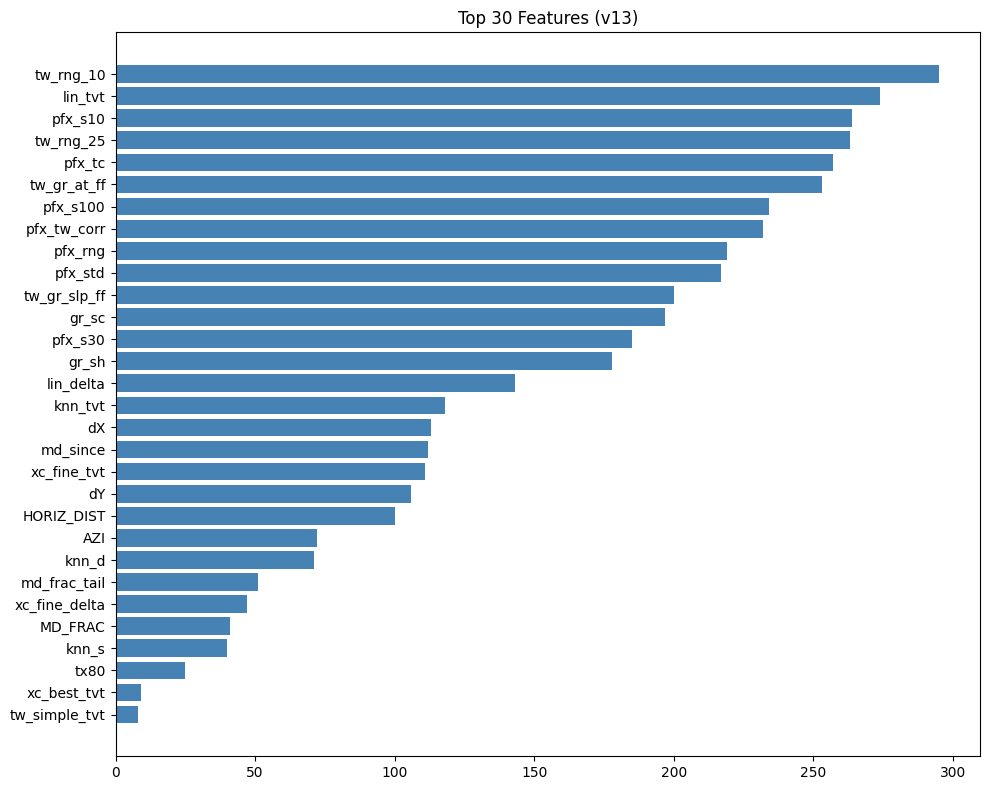

Top 10: ['tw_rng_10', 'lin_tvt', 'pfx_s10', 'tw_rng_25', 'pfx_tc', 'tw_gr_at_ff', 'pfx_s100', 'pfx_tw_corr', 'pfx_rng', 'pfx_std']


In [15]:
# ── 14. FEATURE IMPORTANCE ────────────────────────────────────────────────────
m_lgb = final_models['lgb']
if hasattr(m_lgb,'feature_importances_'):
    fi=pd.DataFrame({'feature':FEAT_COLS,'imp':m_lgb.feature_importances_}
                    ).sort_values('imp',ascending=False).head(30)
    fig,ax=plt.subplots(figsize=(10,8))
    ax.barh(fi['feature'][::-1],fi['imp'][::-1],color='steelblue')
    ax.set_title('Top 30 Features (v13)')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'feat_imp_v13.png'),dpi=100); plt.show()
    print('Top 10:', fi['feature'].head(10).tolist())

In [16]:
# ── 15. ANCHOR FALLBACK FIRST ─────────────────────────────────────────────────
fb_rows=[]
for wid in test_well_ids:
    try:
        hw=load_hw(wid,TEST_DIR); lk=last_known(hw)
        idx=np.flatnonzero(hw['TVT_input'].isna().to_numpy())
        fb_rows.extend({'id':f'{wid}_{i}','tvt':lk} for i in idx)
    except Exception: pass
pd.DataFrame(fb_rows).to_csv(OUT_DIR/'submission_anchor.csv',index=False)
pd.DataFrame(fb_rows).to_csv(OUT_DIR/'submission.csv',index=False)
print(f'Anchor fallback: {len(fb_rows)} rows → submission.csv (safety)')

Anchor fallback: 14151 rows → submission.csv (safety)


In [17]:
# ── 16. TEST PREDICTIONS ──────────────────────────────────────────────────────
def predict_well(wid):
    feat=build_features(wid,TEST_DIR,include_target=False,knn=knn_model,knn_sc=knn_sc)
    if feat is None or len(feat)==0: return None
    X=feat[FEAT_COLS].fillna(TRAIN_MEDS).astype(np.float32)
    lk=float(feat['lk_TVT'].iloc[0])
    delta=sum(final_models[n].predict(X).astype(float)*w
              for (n,_),w in zip(FACTORIES,W) if n in final_models)
    # postprocess_arr directly (no DataFrame needed)
    md_since=feat['md_since'].to_numpy(float)
    md=feat['MD'].to_numpy(float)
    pred=postprocess_arr(delta,lk,md_since,md,ALPHA,TAU,MAX_S)
    return pd.DataFrame({'id':feat['id'].to_numpy(),'tvt':pred})

print('Generating test predictions...')
pred_parts, errors = [], []
for wid in test_well_ids:
    try:
        r=predict_well(wid)
        if r is not None: pred_parts.append(r)
        else:
            hw=load_hw(wid,TEST_DIR); lk=last_known(hw)
            idx=np.flatnonzero(hw['TVT_input'].isna().to_numpy())
            pred_parts.append(pd.DataFrame({'id':[f'{wid}_{i}' for i in idx],'tvt':lk}))
    except Exception as e: errors.append((wid,str(e)))

print(f'{len(pred_parts)} wells, {len(errors)} errors')
if errors: print('Errors:', errors[:5])

Generating test predictions...
3 wells, 0 errors


In [18]:
# ── 17. FINAL SUBMISSION ──────────────────────────────────────────────────────
all_pred=pd.concat(pred_parts,ignore_index=True)
sample=pd.read_csv(SAMPLE_SUB)
final=sample[['id']].merge(all_pred,on='id',how='left')
n_gap=int(final['tvt'].isna().sum())
if n_gap:
    print(f'Filling {n_gap} gaps')
    fb_map={r['id']:r['tvt'] for r in fb_rows}
    final['tvt']=final.apply(
        lambda r: fb_map.get(r['id'],0.) if pd.isna(r['tvt']) else r['tvt'],axis=1)
assert final['tvt'].isna().sum()==0
final[['id','tvt']].to_csv(OUT_DIR/'submission.csv',index=False)
print(f'Rows:{len(final):,}  Mean:{final["tvt"].mean():.3f}  Std:{final["tvt"].std():.3f}')
print('submission.csv ✓')

Rows:14,151  Mean:11907.698  Std:278.934
submission.csv ✓


Model beats anchor: 411 / 773
Row-weighted RMSE (pp)   : 15.4424
Row-weighted RMSE (blend): 15.4482
Anchor                   : 15.9099
           anchor       blend          pp
count  773.000000  773.000000  773.000000
mean    12.812466   12.601722   12.589723
std      8.899487    8.507139    8.513221
min      1.115949    1.508586    1.512745
25%      7.100676    7.036997    7.016660
50%     10.665141   10.374278   10.371648
75%     15.811256   15.535177   15.533420
90%     22.972537   22.472754   22.457237
95%     29.010764   28.853128   28.841515
max     70.639375   68.547076   68.550745


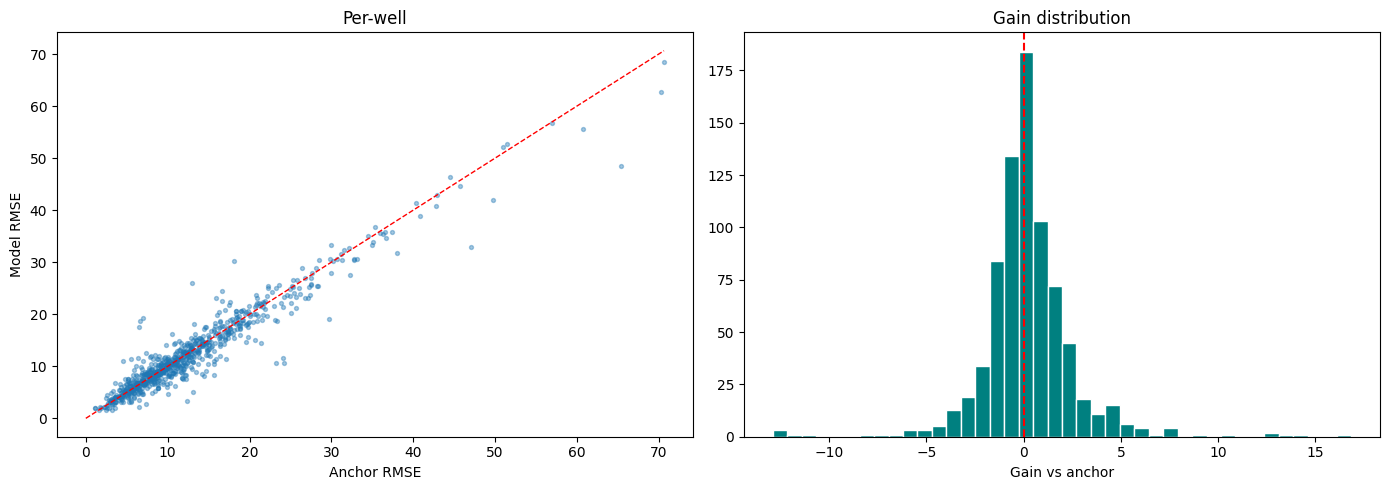

In [19]:
# ── 18. OOF DIAGNOSTICS ───────────────────────────────────────────────────────
pp_tvt=apply_pp(blended_delta,ALPHA,TAU,MAX_S)
well_diag=(
    train_df.assign(blend=anchor_arr+blended_delta,pp=pp_tvt)
    .groupby('well_id')
    .apply(lambda g: pd.Series({
        'anchor':rmse(g['target_tvt'].values,g['lk_TVT'].values),
        'blend' :rmse(g['target_tvt'].values,g['blend'].values),
        'pp'    :rmse(g['target_tvt'].values,g['pp'].values),
        'rows'  :len(g)}))
    .reset_index()
)
well_diag['gain']=well_diag['anchor']-well_diag['pp']
print(f'Model beats anchor: {(well_diag["gain"]>0).sum()} / {len(well_diag)}')
print(f'Row-weighted RMSE (pp)   : {rmse(true_tvt,pp_tvt):.4f}')
print(f'Row-weighted RMSE (blend): {rmse(true_tvt,anchor_arr+blended_delta):.4f}')
print(f'Anchor                   : {rmse(true_tvt,anchor_arr):.4f}')
print(well_diag[['anchor','blend','pp']].describe(percentiles=[.25,.5,.75,.9,.95]))
fig,axes=plt.subplots(1,2,figsize=(14,5))
lim=max(well_diag['anchor'].max(),well_diag['pp'].max())
axes[0].scatter(well_diag['anchor'],well_diag['pp'],alpha=0.4,s=8)
axes[0].plot([0,lim],[0,lim],'r--',lw=1)
axes[0].set(xlabel='Anchor RMSE',ylabel='Model RMSE',title='Per-well')
axes[1].hist(well_diag['gain'],bins=40,color='teal',edgecolor='w')
axes[1].axvline(0,color='red',lw=1.5,ls='--')
axes[1].set(xlabel='Gain vs anchor',title='Gain distribution')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'oof_v13.png'),dpi=100); plt.show()

In [20]:
# ── 19. SANITY CHECK ──────────────────────────────────────────────────────────
sub=pd.read_csv(OUT_DIR/'submission.csv'); samp=pd.read_csv(SAMPLE_SUB)
print('Rows match:', len(sub)==len(samp))
print('IDs  match:', set(sub['id'])==set(samp['id']))
print('NaN  count:', sub['tvt'].isna().sum())
print(sub['tvt'].describe())

Rows match: True
IDs  match: True
NaN  count: 0
count    14151.000000
mean     11907.698483
std        278.934146
min      11603.565783
25%      11605.902850
50%      11749.375169
75%      12225.873669
max      12226.385187
Name: tvt, dtype: float64
